In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.ticker import LogLocator
from matplotlib.colors import BoundaryNorm, ListedColormap

### Degree Distribution

In [2]:

summary_path = "../scripts/results_really_final_draft_DEGREE.csv"
df = pd.read_csv(summary_path)

In [3]:
std_col = "param_0"
alpha_col = "param_1"

df[alpha_col] = df[alpha_col].astype(float)
df[std_col] = df[std_col].astype(float)

std_values = np.sort(df[std_col].unique())

In [16]:
features = ["mean", "std", "p10", "p25", "median", "p75", "p90"]
empirical_values = [126.1, 97, 34, 52, 97, 185, 236]
y_labels = [
    "Mean degree",
    "Standard deviation (of degree distribution)",
    r"$10^{\mathrm{th}}$ percentile degree",
    r"$25^{\mathrm{th}}$ percentile degree",
    "Median degree",
    r"$75^{\mathrm{th}}$ percentile degree",
    r"$90^{\mathrm{th}}$ percentile degree",
]
sigma_ticks = np.array([0.1, 0.125, 0.15, 0.175, 0.2]) #CHANGE HERE IF NEEDED
sigma_ticklabels = ["0.1", "0.125", "0.15", "0.175", "0.2"] #CHANGE HERE IF NEEDED

In [19]:
# Sample exactly one color per sigma value.
sigma_colors = plt.cm.turbo(
    np.linspace(0.15, 0.85, len(sigma_ticks))
)
cmap = ListedColormap(sigma_colors)

# Boundaries halfway between adjacent sigma values.
sigma_boundaries = np.concatenate([
    [sigma_ticks[0] - (sigma_ticks[1] - sigma_ticks[0]) / 2],
    (sigma_ticks[:-1] + sigma_ticks[1:]) / 2,
    [sigma_ticks[-1] + (sigma_ticks[-1] - sigma_ticks[-2]) / 2],
])

norm = BoundaryNorm(
    sigma_boundaries,
    cmap.N,
)

Plotting mean vs alpha


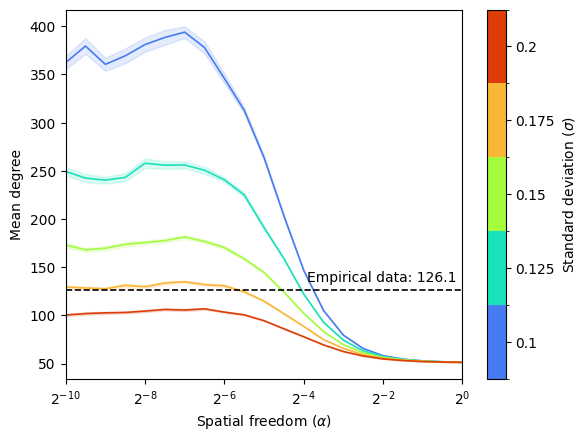

Plotting std vs alpha


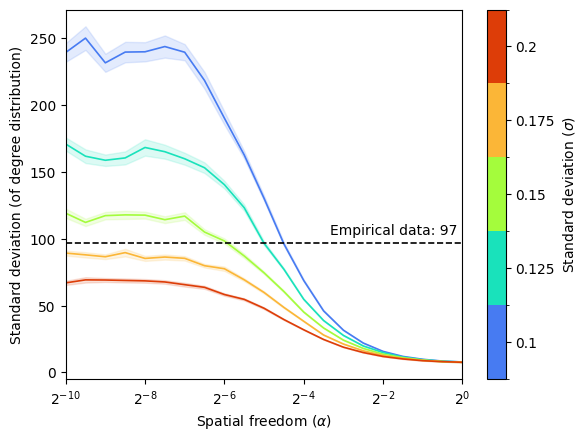

Plotting p10 vs alpha


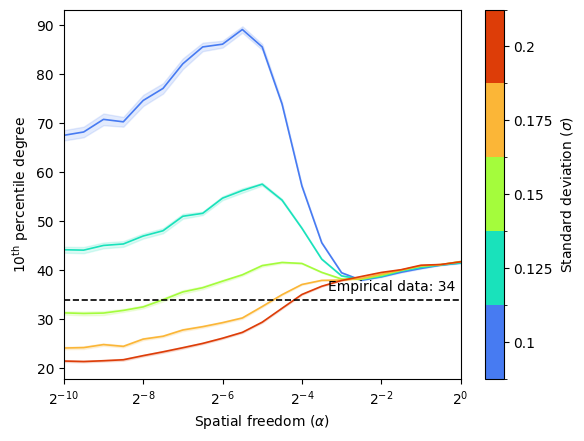

Plotting p25 vs alpha


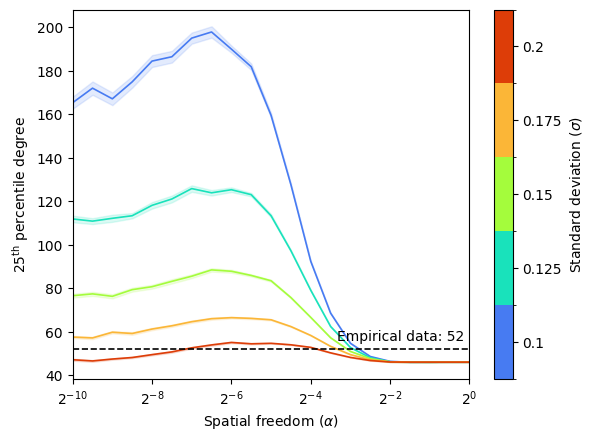

Plotting median vs alpha


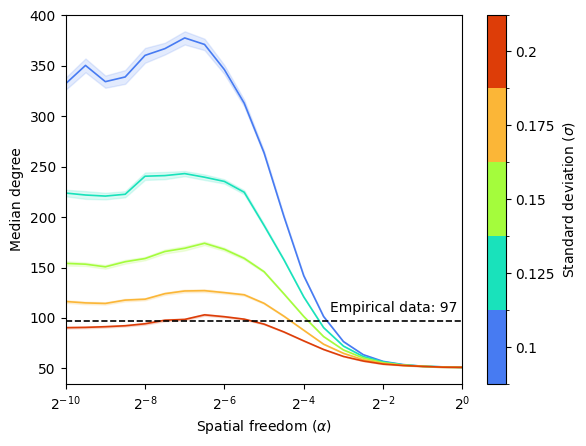

Plotting p75 vs alpha


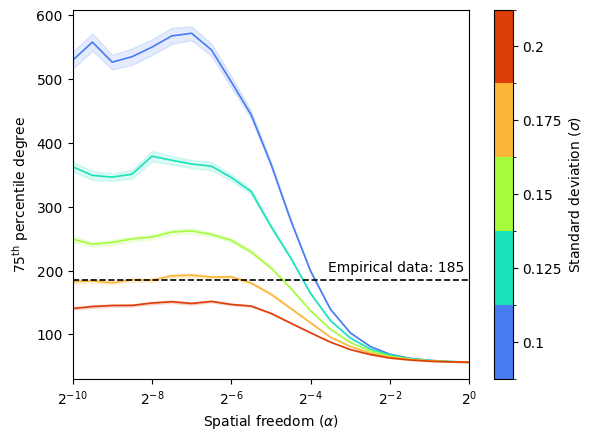

Plotting p90 vs alpha


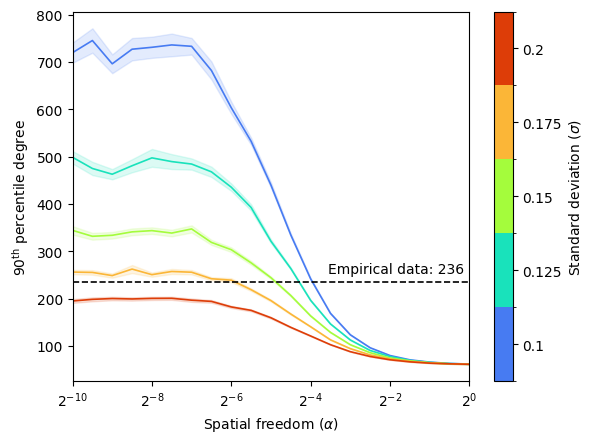

In [20]:
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

tick_exponents = np.arange(-10, 1, 2)
alpha_ticks = 2.0 ** tick_exponents

for feature, empirical_value, y_label in zip(
    features,
    empirical_values,
    y_labels,
):
    se_col = f"se_{feature}"

    if feature not in df.columns:
        raise KeyError(
            f"Column '{feature}' is missing from the CSV."
        )

    if se_col not in df.columns:
        raise KeyError(
            f"Column '{se_col}' is missing from the CSV."
        )

    print(f"Plotting {feature} vs alpha")

    fig, ax = plt.subplots()

    for std in std_values:
        sub = (
            df[df[std_col] == std]
            .sort_values(alpha_col)
        )

        alphas = sub[alpha_col].to_numpy(dtype=float)
        values = sub[feature].to_numpy(dtype=float)
        ses = sub[se_col].to_numpy(dtype=float)

        color = cmap(norm(std))

        lower = values - ses
        upper = values + ses

        # Required because the y-axis is logarithmic.
        valid_line = (
            np.isfinite(alphas)
            & np.isfinite(values)
            & (alphas > 0)
            & (values > 0)
        )

        ax.plot(
            alphas[valid_line],
            values[valid_line],
            color=color,
            linewidth=1.2,
        )

        # fill_between does not support non-positive values on a log axis.
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        ax.fill_between(
            alphas,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        boundaries=sigma_boundaries,
        ticks=sigma_ticks,
        spacing="uniform",
    )
    cbar.set_label(r"Standard deviation ($\sigma$)")
    cbar.set_ticklabels(sigma_ticklabels)

    # Base-2 logarithmic alpha axis.
    ax.set_xscale("log", base=2)
    ax.set_xlim(2**-10, 1)
    ax.set_xticks(alpha_ticks)
    ax.set_xticklabels([
        rf"$2^{{{exponent}}}$"
        for exponent in tick_exponents
    ])

    # Empirical reference.
    ax.axhline(
        empirical_value,
        color="black",
        linestyle="--",
        linewidth=1.2,
    )

    ax.annotate(
        f"Empirical data: {empirical_value:g}",
        xy=(1, empirical_value),
        xytext=(-4, 4),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=10,
    )

    ax.set_xlabel(r"Spatial freedom ($\alpha$)")
    ax.set_ylabel(y_label)

    fig.savefig(
        f"fitting_degree_{feature}_vs_alpha_by_std_100.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

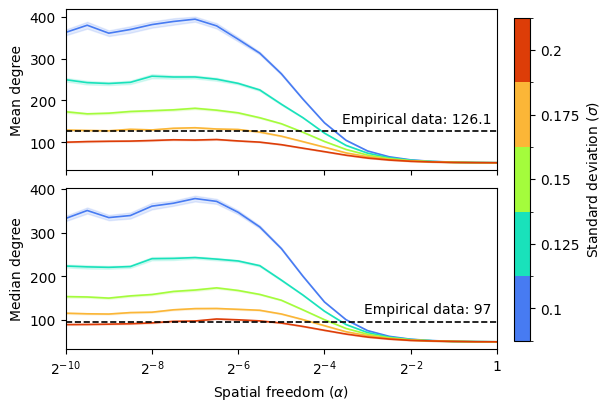

In [25]:
plot_features = [
    "mean",
    "median",
]

plot_se_columns = [
    "se_mean",
    "se_median",
]

plot_labels = [
    "Mean degree",
    "Median degree",
]

empirical_values = [
    126.1,
    97,
]

for column in plot_features + plot_se_columns:
    if column not in df.columns:
        raise KeyError(
            f"Column '{column}' is missing from the CSV."
        )

fig, axes = plt.subplots(
    2,
    1,
    figsize=(6, 4),
    sharex=True,
    constrained_layout=True,
)

for (
    ax,
    feature,
    se_col,
    y_label,
    empirical_value,
) in zip(
    axes,
    plot_features,
    plot_se_columns,
    plot_labels,
    empirical_values,
):
    for std in std_values:
        sub = (
            df[df[std_col] == std]
            .sort_values(alpha_col)
        )

        alphas = sub[alpha_col].to_numpy(dtype=float)
        values = sub[feature].to_numpy(dtype=float)
        ses = sub[se_col].to_numpy(dtype=float)

        color = cmap(norm(std))

        valid_line = (
            np.isfinite(alphas)
            & np.isfinite(values)
            & (alphas > 0)
        )

        ax.plot(
            alphas[valid_line],
            values[valid_line],
            color=color,
            linewidth=1.2,
        )

        lower = values - ses
        upper = values + ses

        valid_band = (
            np.isfinite(alphas)
            & np.isfinite(lower)
            & np.isfinite(upper)
            & (alphas > 0)
        )

        ax.fill_between(
            alphas[valid_band],
            lower[valid_band],
            upper[valid_band],
            color=color,
            alpha=0.15,
        )

    ax.axhline(
        empirical_value,
        color="black",
        linestyle="--",
        linewidth=1.2,
    )

    ax.annotate(
        f"Empirical data: {empirical_value:g}",
        xy=(1, empirical_value),
        xytext=(-4, 4),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=10,
    )

    ax.set_ylabel(y_label)

# Shared base-2 logarithmic x-axis.
axes[-1].set_xscale("log", base=2)
axes[-1].set_xlim(2**-10, 1)
axes[-1].set_xticks(alpha_ticks)
axes[-1].set_xticklabels([
    "1" if exponent == 0 else rf"$2^{{{exponent}}}$"
    for exponent in tick_exponents
])
axes[-1].set_xlabel(r"Spatial freedom ($\alpha$)")

# Hide duplicate x tick labels on the upper subplot.
axes[0].tick_params(labelbottom=False)

# Shared colorbar on the right of both plots.
sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    location="right",
    pad=0.03,
    shrink=0.95,
)

cbar.set_label(r"Standard deviation ($\sigma$)")
cbar.set_ticks(std_values)
cbar.set_ticklabels(sigma_ticklabels)

fig.savefig(
    "fitting_mean_median_vs_alpha_by_std.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

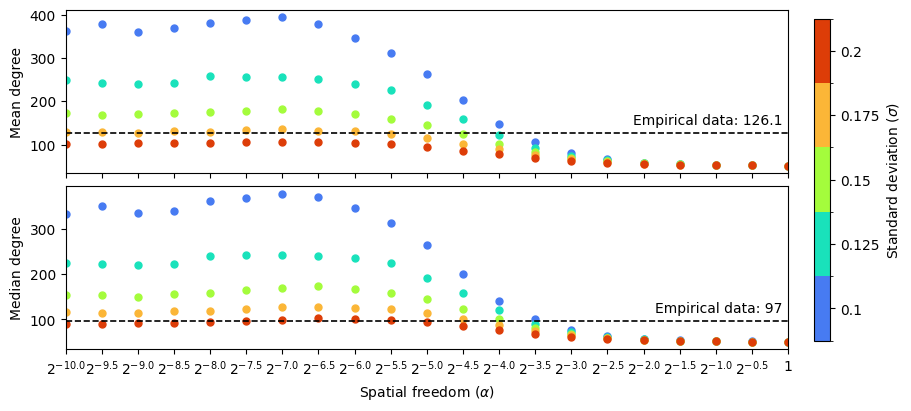

In [42]:
alpha_ticks = np.array([(1/2)**(i/2) for i in range(21)]) # COMMENT OUT
tick_exponents = [(-i/2) for i in range(21)] # COMMENT OUT

plot_features = [
    "mean",
    "median",
]

plot_se_columns = [
    "se_mean",
    "se_median",
]

plot_labels = [
    "Mean degree",
    "Median degree",
]

empirical_values = [
    126.1,
    97,
]

for column in plot_features + plot_se_columns:
    if column not in df.columns:
        raise KeyError(
            f"Column '{column}' is missing from the CSV."
        )

fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 4),
    sharex=True,
    constrained_layout=True,
)

for (
    ax,
    feature,
    se_col,
    y_label,
    empirical_value,
) in zip(
    axes,
    plot_features,
    plot_se_columns,
    plot_labels,
    empirical_values,
):
    for std in std_values:
        sub = (
            df[df[std_col] == std]
            .sort_values(alpha_col)
        )

        alphas = sub[alpha_col].to_numpy(dtype=float)
        values = sub[feature].to_numpy(dtype=float)
        ses = sub[se_col].to_numpy(dtype=float)

        color = cmap(norm(std))

        valid_line = (
            np.isfinite(alphas)
            & np.isfinite(values)
            & (alphas > 0)
        )

        """ax.plot(
            alphas[valid_line],
            values[valid_line],
            color=color,
            linewidth=1.2,
        )"""

        ax.scatter(
        alphas[valid_line],
        values[valid_line],
        color=color,
        s=25,
    )

        """lower = values - ses
        upper = values + ses

        valid_band = (
            np.isfinite(alphas)
            & np.isfinite(lower)
            & np.isfinite(upper)
            & (alphas > 0)
        )

        ax.fill_between(
            alphas[valid_band],
            lower[valid_band],
            upper[valid_band],
            color=color,
            alpha=0.15,
        )"""

    ax.axhline(
        empirical_value,
        color="black",
        linestyle="--",
        linewidth=1.2,
    )

    ax.annotate(
        f"Empirical data: {empirical_value:g}",
        xy=(1, empirical_value),
        xytext=(-4, 4),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=10,
    )

    ax.set_ylabel(y_label)

# Shared base-2 logarithmic x-axis.
axes[-1].set_xscale("log", base=2)
axes[-1].set_xlim(2**-10, 1)
axes[-1].set_xticks(alpha_ticks)
axes[-1].set_xticklabels([
    "1" if exponent == 0 else rf"$2^{{{exponent}}}$"
    for exponent in tick_exponents
])
axes[-1].set_xlabel(r"Spatial freedom ($\alpha$)")

# Hide duplicate x tick labels on the upper subplot.
axes[0].tick_params(labelbottom=False)

# Shared colorbar on the right of both plots.
sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    location="right",
    pad=0.03,
    shrink=0.95,
)

cbar.set_label(r"Standard deviation ($\sigma$)")
cbar.set_ticks(std_values)
cbar.set_ticklabels(sigma_ticklabels)

fig.savefig(
    "fitting_mean_median_vs_alpha_by_std.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

### Mean Squared Error

In [29]:
empirical_mean = 126.1
empirical_median = 97

df_fit = df.copy()

df_fit["mean_sq_error"] = (
    df_fit["mean"] - empirical_mean
) ** 2

df_fit["median_sq_error"] = (
    df_fit["median"] - empirical_median
) ** 2

df_fit["average_mse"] = (
    df_fit["mean_sq_error"]
    + df_fit["median_sq_error"]
) / 2

best = df_fit.loc[df_fit["average_mse"].idxmin()]

top10 = (
    df_fit
    .sort_values("average_mse")
    .head(10)
    [[
        "param_0",          # sigma
        "param_1",          # alpha
        "mean",
        "median",
        "mean_sq_error",
        "median_sq_error",
        "average_mse",
    ]]
)

print(top10.to_string(index=False))

 param_0  param_1       mean  median  mean_sq_error  median_sq_error  average_mse
   0.175 0.001953 127.613620  114.36       2.291046         301.3696   151.830323
   0.175 0.001381 128.377300  114.90       5.186095         320.4100   162.798048
   0.175 0.000977 129.360828  116.28      10.632999         371.7184   191.175700
   0.200 0.005524 106.103580   97.70     399.856813           0.4900   200.173406
   0.200 0.011049 106.780704  103.06     373.235198          36.7236   204.979399
   0.200 0.007812 105.480088   98.50     425.180771           2.2500   213.715385
   0.175 0.031250 114.739104  114.48     129.069958         305.5504   217.310179
   0.175 0.002762 131.081744  117.66      24.817773         426.8356   225.826687
   0.100 0.088388 104.944148  101.44     447.570074          19.7136   233.641837
   0.175 0.003906 129.632248  118.56      12.476776         464.8336   238.655188


In [30]:
sigma = 0.15
alpha = 2**-4

print(
    df_fit.loc[
        np.isclose(df_fit["param_0"], sigma)
        & np.isclose(df_fit["param_1"], alpha),
        [
            "param_0",
            "param_1",
            "mean",
            "median",
            "mean_sq_error",
            "median_sq_error",
            "average_mse",
        ],
    ]
)

    param_0  param_1        mean  median  mean_sq_error  median_sq_error  \
54     0.15   0.0625  102.163032  101.46     572.978437          19.8916   

    average_mse  
54   296.435019  


In [47]:
feature = "median"

mse_by_std = {}

for std in std_values:
    sub = (
        df[df[std_col] == std]
        .sort_values(alpha_col)
    )

    values = sub[feature].to_numpy(dtype=float)

    mse = np.mean((values - empirical_value)**2)
    mse_by_std[std] = mse

print(mse_by_std)

{np.float64(0.1): np.float64(32923.362799999995), np.float64(0.125): np.float64(9819.82300952381), np.float64(0.15): np.float64(2703.2983619047627), np.float64(0.175): np.float64(917.5771619047619), np.float64(0.2): np.float64(684.8980952380953)}


### Mean Absolute Error

In [32]:
df_fit["average_mae"] = (
    np.abs(df_fit["mean"] - empirical_mean)
    + np.abs(df_fit["median"] - empirical_median)
) / 2

best_mae = df_fit.loc[df_fit["average_mae"].idxmin()]

top10_mae = (
    df_fit
    .sort_values("average_mae")
    .head(10)
    [[
        "param_0",          # sigma
        "param_1",          # alpha
        "mean",
        "median",
        "average_mae",
    ]]
)

print(top10_mae.to_string(index=False))

 param_0  param_1       mean  median  average_mae
   0.175 0.001953 127.613620  114.36     9.436810
   0.175 0.001381 128.377300  114.90    10.088650
   0.200 0.005524 106.103580   97.70    10.348210
   0.200 0.007812 105.480088   98.50    11.059956
   0.175 0.000977 129.360828  116.28    11.270414
   0.200 0.003906 104.421108   94.20    12.239446
   0.175 0.003906 129.632248  118.56    12.546124
   0.200 0.011049 106.780704  103.06    12.689648
   0.100 0.088388 104.944148  101.44    12.797926
   0.175 0.002762 131.081744  117.66    12.820872


In [35]:
sigma = 0.15
alpha = 2**-4

print(
    df_fit.loc[
        np.isclose(df_fit["param_0"], sigma)
        & np.isclose(df_fit["param_1"], alpha),
        [
            "param_0",
            "param_1",
            "mean",
            "median",
            "average_mse",
            "average_mae",
        ],
    ]
)

    param_0  param_1        mean  median  average_mse  average_mae
54     0.15   0.0625  102.163032  101.46   296.435019    14.198484


In [55]:
feature = "median"

mae_by_std = {}

for std in std_values:
    sub = (
        df[df[std_col] == std]
        .sort_values(alpha_col)
    )

    values = sub[feature].to_numpy(dtype=float)

    mae = np.mean(np.abs(values - empirical_value))
    mae_by_std[std] = mae

print(mae_by_std)

{np.float64(0.1): np.float64(148.34190476190474), np.float64(0.125): np.float64(86.2095238095238), np.float64(0.15): np.float64(48.66095238095238), np.float64(0.175): np.float64(27.882857142857148), np.float64(0.2): np.float64(19.120000000000005)}


### Average Alter Distance Distribution

In [42]:

summary_path = "../scripts/final_draft_100_avg_alter_dist_distribution_stats.csv"
df = pd.read_csv(summary_path)

In [43]:
std_col = "param_0"
alpha_col = "param_1"

df[alpha_col] = df[alpha_col].astype(float)
df[std_col] = df[std_col].astype(float)

std_values = np.sort(df[std_col].unique())

In [44]:
features = ["mean", "std", "p10", "p25", "median", "p75", "p90"]
empirical_values = [13.896, 14.220, 1.188, 4.107, 9.822, 19.024, 31.545]
#empirical_values = [val / 312 for val in empirical_values]
y_labels = [
    "Mean Average Alter Distance",
    "Standard Deviation (of Average Alter Distance Distribution)",
    r"$10^{\mathrm{th}}$ Percentile Average Alter Distance",
    r"$25^{\mathrm{th}}$ Percentile Average Alter Distance",
    "Median Average Alter Distance",
    r"$75^{\mathrm{th}}$ Percentile Average Alter Distance",
    r"$90^{\mathrm{th}}$ Percentile Average Alter Distance",
]

Plotting mean vs alpha


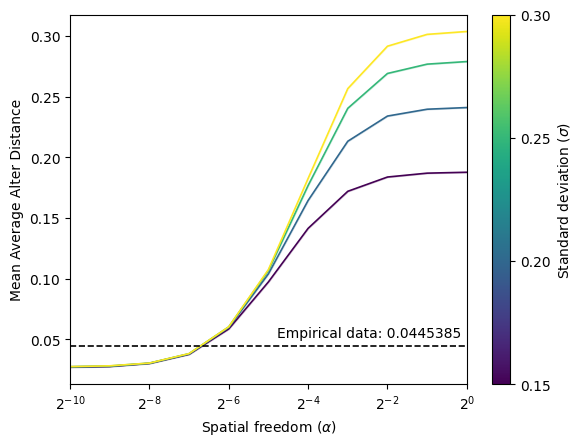

Plotting std vs alpha


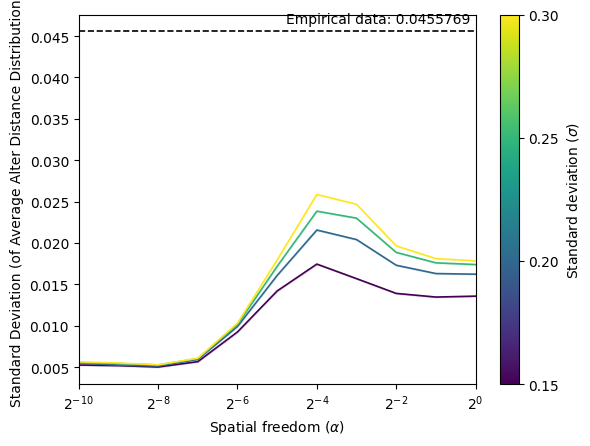

Plotting p10 vs alpha


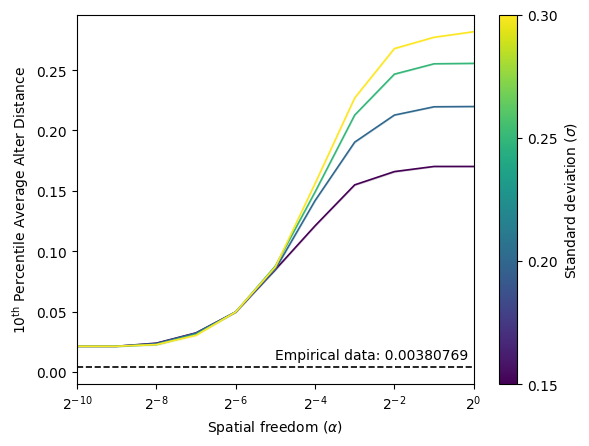

Plotting p25 vs alpha


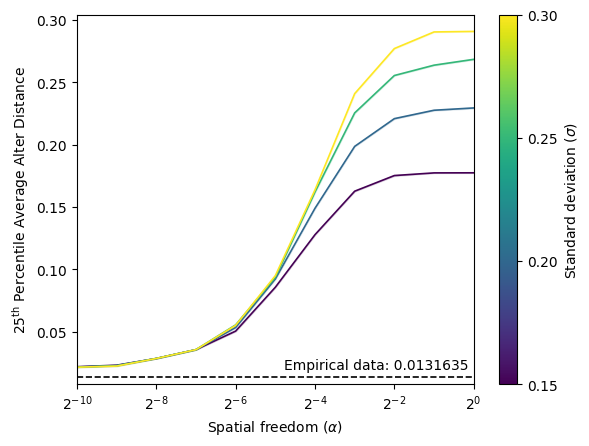

Plotting median vs alpha


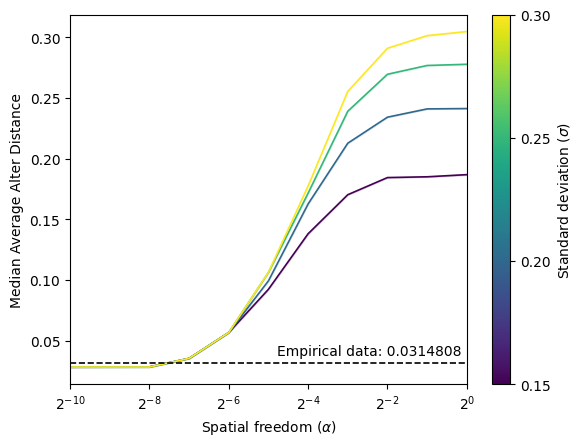

Plotting p75 vs alpha


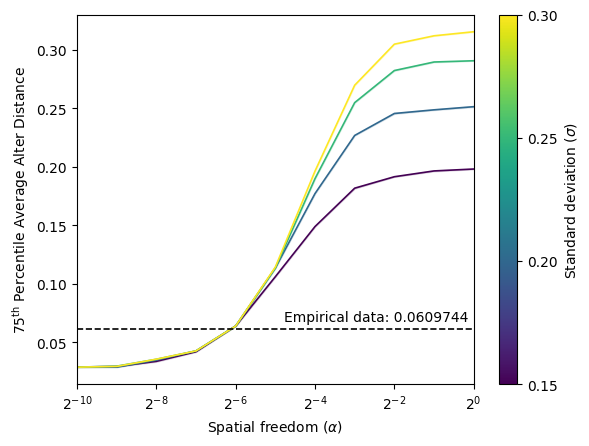

Plotting p90 vs alpha


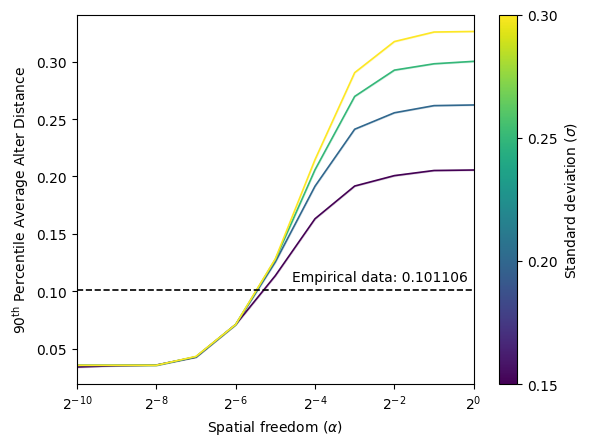

In [45]:
cmap = plt.cm.viridis
norm = Normalize(
    vmin=std_values.min(),
    vmax=std_values.max(),
)

tick_exponents = np.arange(-10, 1, 2)
alpha_ticks = 2.0 ** tick_exponents

for feature, empirical_value, y_label in zip(
    features,
    empirical_values,
    y_labels,
):
    se_col = f"se_{feature}"

    if feature not in df.columns:
        raise KeyError(
            f"Column '{feature}' is missing from the CSV."
        )

    if se_col not in df.columns:
        raise KeyError(
            f"Column '{se_col}' is missing from the CSV."
        )

    print(f"Plotting {feature} vs alpha")

    fig, ax = plt.subplots()

    for std in std_values:
        sub = (
            df[df[std_col] == std]
            .sort_values(alpha_col)
        )

        alphas = sub[alpha_col].to_numpy(dtype=float)
        values = (sub[feature]/1.41).to_numpy(dtype=float)
        ses = (sub[se_col]/1.41).to_numpy(dtype=float)

        color = cmap(norm(std))

        lower = values - ses
        upper = values + ses

        # Required because the y-axis is logarithmic.
        valid_line = (
            np.isfinite(alphas)
            & np.isfinite(values)
            & (alphas > 0)
            & (values > 0)
        )

        ax.plot(
            alphas[valid_line],
            values[valid_line],
            color=color,
            linewidth=1.2,
        )

        # fill_between does not support non-positive values on a log axis.
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        ax.fill_between(
            alphas,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r"Standard deviation ($\sigma$)")
    cbar.set_ticks(std_values)
    cbar.set_ticklabels([
        f"{std:.2f}"
        for std in std_values
    ])

    # Base-2 logarithmic alpha axis.
    ax.set_xscale("log", base=2)
    ax.set_xlim(2**-10, 1)
    ax.set_xticks(alpha_ticks)
    ax.set_xticklabels([
        rf"$2^{{{exponent}}}$"
        for exponent in tick_exponents
    ])

    # Empirical reference.
    ax.axhline(
        (empirical_value/312),
        color="black",
        linestyle="--",
        linewidth=1.2,
    )

    ax.annotate(
        f"Empirical data: {(empirical_value/312):g}",
        xy=(1, (empirical_value/312)),
        xytext=(-4, 4),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=10,
    )

    ax.set_xlabel(r"Spatial freedom ($\alpha$)")
    ax.set_ylabel(y_label)

    fig.savefig(
        f"fitting_avg_alter_dist_{feature}_vs_alpha_by_std_100.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

### Clustering Distribution

In [46]:

summary_path = "../scripts/final_draft_100_local_clustering_distribution_stats.csv"
df = pd.read_csv(summary_path)

In [47]:
std_col = "param_0"
alpha_col = "param_1"

df[alpha_col] = df[alpha_col].astype(float)
df[std_col] = df[std_col].astype(float)

std_values = np.sort(df[std_col].unique())

In [48]:
features = ["mean", "std", "p10", "p25", "median", "p75", "p90"]
empirical_values = [0.406, 0.157, 0.243, 0.302, 0.378, 0.472, 0.601]
y_labels = [
    "Mean local clustering",
    "Standard deviation (of local clustering distribution)",
    r"$10^{\mathrm{th}}$ percentile local clustering",
    r"$25^{\mathrm{th}}$ percentile local clustering",
    "Median local clustering",
    r"$75^{\mathrm{th}}$ percentile local clustering",
    r"$90^{\mathrm{th}}$ percentile local clustering",
]

Plotting mean vs alpha


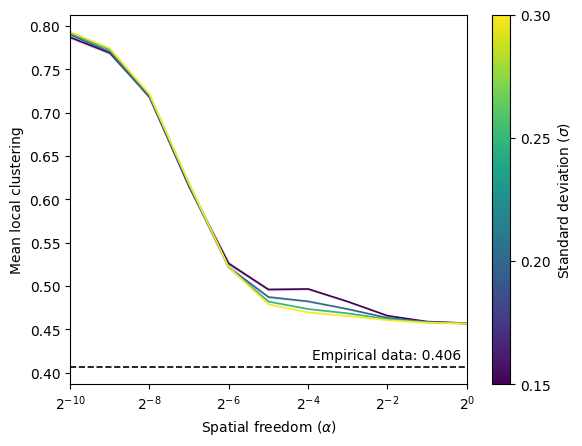

Plotting std vs alpha


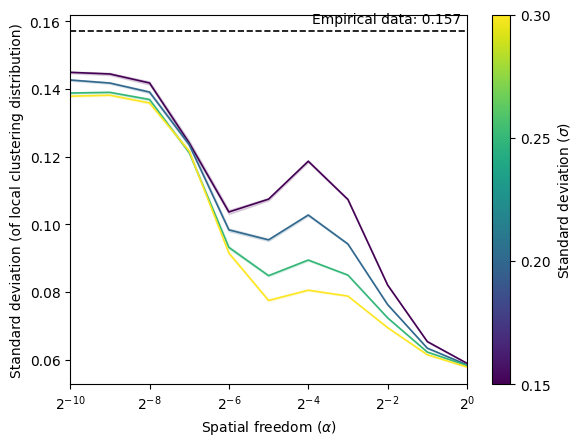

Plotting p10 vs alpha


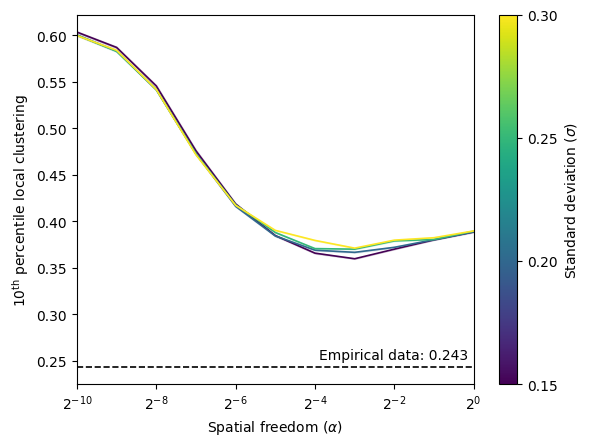

Plotting p25 vs alpha


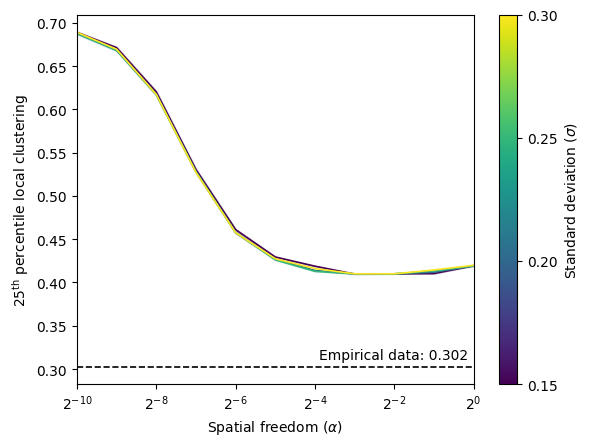

Plotting median vs alpha


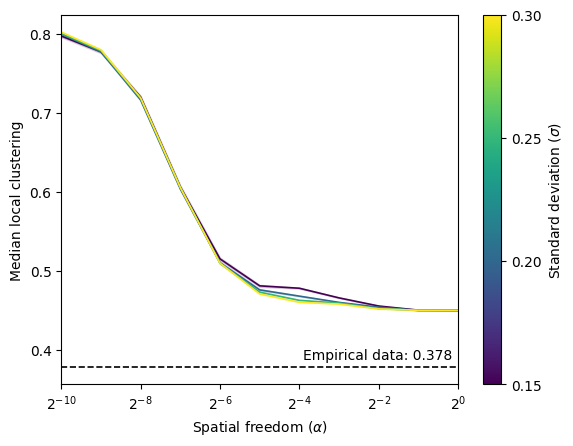

Plotting p75 vs alpha


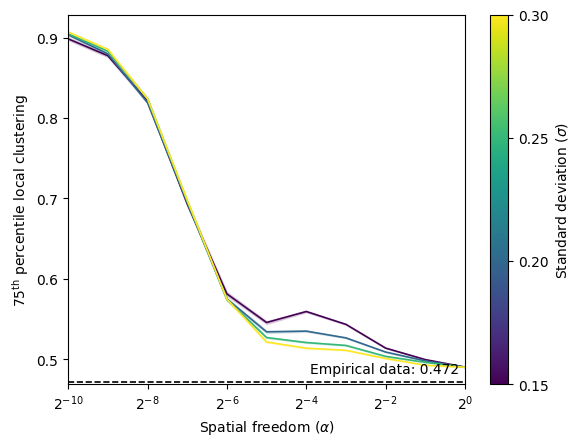

Plotting p90 vs alpha


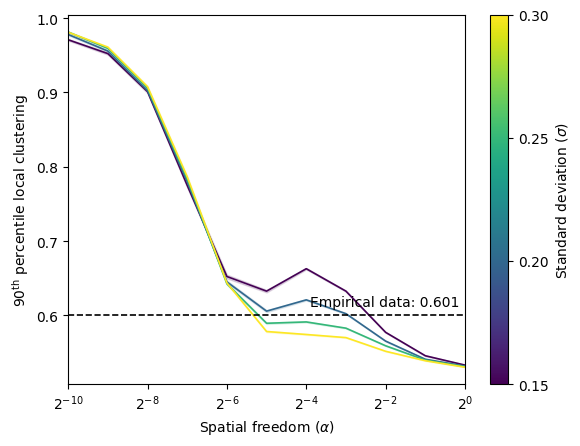

In [49]:
cmap = plt.cm.viridis
norm = Normalize(
    vmin=std_values.min(),
    vmax=std_values.max(),
)

tick_exponents = np.arange(-10, 1, 2)
alpha_ticks = 2.0 ** tick_exponents

for feature, empirical_value, y_label in zip(
    features,
    empirical_values,
    y_labels,
):
    se_col = f"se_{feature}"

    if feature not in df.columns:
        raise KeyError(
            f"Column '{feature}' is missing from the CSV."
        )

    if se_col not in df.columns:
        raise KeyError(
            f"Column '{se_col}' is missing from the CSV."
        )

    print(f"Plotting {feature} vs alpha")

    fig, ax = plt.subplots()

    for std in std_values:
        sub = (
            df[df[std_col] == std]
            .sort_values(alpha_col)
        )

        alphas = sub[alpha_col].to_numpy(dtype=float)
        values = sub[feature].to_numpy(dtype=float)
        ses = sub[se_col].to_numpy(dtype=float)

        color = cmap(norm(std))

        lower = values - ses
        upper = values + ses

        # Required because the y-axis is logarithmic.
        valid_line = (
            np.isfinite(alphas)
            & np.isfinite(values)
            & (alphas > 0)
            & (values > 0)
        )

        ax.plot(
            alphas[valid_line],
            values[valid_line],
            color=color,
            linewidth=1.2,
        )

        # fill_between does not support non-positive values on a log axis.
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        ax.fill_between(
            alphas,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r"Standard deviation ($\sigma$)")
    cbar.set_ticks(std_values)
    cbar.set_ticklabels([
        f"{std:.2f}"
        for std in std_values
    ])

    # Base-2 logarithmic alpha axis.
    ax.set_xscale("log", base=2)
    ax.set_xlim(2**-10, 1)
    ax.set_xticks(alpha_ticks)
    ax.set_xticklabels([
        rf"$2^{{{exponent}}}$"
        for exponent in tick_exponents
    ])

    # Empirical reference.
    ax.axhline(
        empirical_value,
        color="black",
        linestyle="--",
        linewidth=1.2,
    )

    ax.annotate(
        f"Empirical data: {empirical_value:g}",
        xy=(1, empirical_value),
        xytext=(-4, 4),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=10,
    )

    ax.set_xlabel(r"Spatial freedom ($\alpha$)")
    ax.set_ylabel(y_label)

    fig.savefig(
        f"fitting_clustering_{feature}_vs_alpha_by_std_100.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

### Per Seed Error - Degree Distribution

In [62]:
summary_path = "../scripts/results_really_final_draft_DEGREE_per_seed.csv"
df = pd.read_csv(summary_path)

std_col = "param_0"
alpha_col = "param_1"

df[alpha_col] = df[alpha_col].astype(float)
df[std_col] = df[std_col].astype(float)

std_values = np.sort(df[std_col].unique())

In [63]:
empirical_mean = 126.1
empirical_median = 97
empirical_25th = 52
epirical_75th = 185

df["mean_absolute_error"] = np.abs(
    df["mean"] - empirical_mean
)

df["median_absolute_error"] = np.abs(
    df["median"] - empirical_median
)

df["25th_absolute_error"] = np.abs(
    df["p25"] - empirical_25th
)

df["75th_absolute_error"] = np.abs(
    df["p75"] - epirical_75th
)

df["combined_absolute_error"] = (
    df["mean_absolute_error"]
    + df["median_absolute_error"]
    + df["25th_absolute_error"]
    + df["75th_absolute_error"]
) / 4

mae_by_std = (
    df
    .groupby(std_col)
    .agg(
        mean_mae=("mean_absolute_error", "mean"),
        median_mae=("median_absolute_error", "mean"),
        p25_mae=("25th_absolute_error", "mean"),
        p75_mae=("75th_absolute_error", "mean"),
        combined_mae=("combined_absolute_error", "mean"),
        n_rows=("combined_absolute_error", "size"),
        n_seeds=("seed", "nunique"),
        n_alphas=(alpha_col, "nunique"),
    )
    .sort_values("combined_mae")
)

print(mae_by_std)

           mean_mae  median_mae    p25_mae     p75_mae  combined_mae  n_rows  \
param_0                                                                        
0.175     33.464662   27.890476   8.083810   57.714286     31.788308    1050   
0.200     43.044864   20.076190   3.887619   73.409524     35.104549    1050   
0.150     49.495467   48.666667  19.568571   77.823810     48.888629    1050   
0.125     86.386993   86.209524  40.155238  130.280952     85.758177    1050   
0.100    149.336991  148.341905  74.744762  219.812381    148.059010    1050   

         n_seeds  n_alphas  
param_0                     
0.175         50        21  
0.200         50        21  
0.150         50        21  
0.125         50        21  
0.100         50        21  


In [64]:
empirical_mean = 126.1
empirical_median = 97
empirical_25th = 52
empirical_75th = 185

df["mean_squared_error"] = (
    df["mean"] - empirical_mean
) ** 2

df["median_squared_error"] = (
    df["median"] - empirical_median
) ** 2

df["25th_squared_error"] = (
    df["p25"] - empirical_25th
) ** 2

df["75th_squared_error"] = (
    df["p75"] - empirical_75th
) ** 2

df["combined_squared_error"] = (
    df["mean_squared_error"]
    + df["median_squared_error"]
    + df["25th_squared_error"]
    + df["75th_squared_error"]
) / 4

mse_by_std = (
    df
    .groupby(std_col)
    .agg(
        mean_mse=("mean_squared_error", "mean"),
        median_mse=("median_squared_error", "mean"),
        p25_mse=("25th_squared_error", "mean"),
        p75_mse=("75th_squared_error", "mean"),
        combined_mse=("combined_squared_error", "mean"),
        n_rows=("combined_squared_error", "size"),
        n_seeds=("seed", "nunique"),
        n_alphas=(alpha_col, "nunique"),
    )
    .sort_values("combined_mse")
)

print(mse_by_std)

             mean_mse    median_mse      p25_mse       p75_mse  combined_mse  \
param_0                                                                        
0.175     1958.246029    954.911429    85.598095   5791.567619   2197.580793   
0.200     2365.015184    702.767619    20.177143   6910.544762   2499.626177   
0.150     2903.634678   2785.961905   551.926667   7541.140000   3445.665812   
0.125     9131.809019  10048.262857  2490.644762  20352.658095  10505.843683   
0.100    31712.782807  33775.115238  9105.956190  67771.873333  35591.431892   

         n_rows  n_seeds  n_alphas  
param_0                             
0.175      1050       50        21  
0.200      1050       50        21  
0.150      1050       50        21  
0.125      1050       50        21  
0.100      1050       50        21  


In [65]:
empirical_mean = 126.1
empirical_median = 97
empirical_25th = 52
empirical_75th = 185

sigma = 0.175

sub = df[df["param_0"] == sigma].copy()

sub["mean_absolute_error"] = np.abs(
    sub["mean"] - empirical_mean
)

sub["median_absolute_error"] = np.abs(
    sub["median"] - empirical_median
)

sub["25th_absolute_error"] = np.abs(
    sub["p25"] - empirical_25th
)

sub["75th_absolute_error"] = np.abs(
    sub["p75"] - empirical_75th
)

sub["combined_absolute_error"] = (
    sub["mean_absolute_error"]
    + sub["median_absolute_error"]
    + sub["25th_absolute_error"]
    + sub["75th_absolute_error"]
) / 4

mae_by_alpha = (
    sub
    .groupby("param_1")
    .agg(
        mean_mae=("mean_absolute_error", "mean"),
        median_mae=("median_absolute_error", "mean"),
        p25_mae=("25th_absolute_error", "mean"),
        p75_mae=("75th_absolute_error", "mean"),
        combined_mae=("combined_absolute_error", "mean"),
        n_rows=("combined_absolute_error", "size"),
        n_seeds=("seed", "nunique"),
    )
    .sort_values("combined_mae")
)

print(mae_by_alpha)

           mean_mae  median_mae  p25_mae  p75_mae  combined_mae  n_rows  \
param_1                                                                   
0.001953   6.780468       17.40     7.74    12.86     11.195117      50   
0.000977   7.952028       19.28     5.60    15.06     11.973007      50   
0.001381   8.570004       17.90     5.52    15.92     11.977501      50   
0.002762  10.383136       20.66     7.20    15.56     13.450784      50   
0.003906   8.558808       21.56     9.20    14.84     13.539702      50   
0.022097   5.734020       25.94    14.10    11.68     14.363505      50   
0.005524   9.782040       27.04    10.70    14.46     15.495510      50   
0.015625   8.229352       28.08    14.44    13.46     16.052338      50   
0.011049   7.794424       30.02    13.96    13.34     16.278606      50   
0.031250  11.627464       17.48    13.46    22.72     16.321866      50   
0.007812  10.175072       29.72    12.58    14.16     16.658768      50   
0.044194  24.385660      

In [59]:
empirical_mean = 126.1
empirical_median = 97

sigma = 0.175

sub = df[df["param_0"] == sigma].copy()

sub["mean_squared_error"] = (
    sub["mean"] - empirical_mean
) ** 2

sub["median_squared_error"] = (
    sub["median"] - empirical_median
) ** 2

sub["combined_squared_error"] = (
    sub["mean_squared_error"]
    + sub["median_squared_error"]
) / 2

mse_by_alpha = (
    sub
    .groupby("param_1")
    .agg(
        mean_mse=("mean_squared_error", "mean"),
        median_mse=("median_squared_error", "mean"),
        combined_mse=("combined_squared_error", "mean"),
        n_rows=("combined_squared_error", "size"),
        n_seeds=("seed", "nunique"),
    )
    .sort_values("combined_mse")
)

print(mse_by_alpha)

             mean_mse  median_mse  combined_mse  n_rows  n_seeds
param_1                                                         
0.001953    78.053905      367.44    222.746953      50       50
0.031250   161.447762      328.32    244.883881      50       50
0.001381   128.070776      404.14    266.105388      50       50
0.000977   119.245564      466.00    292.622782      50       50
0.003906   110.369039      525.44    317.904519      50       50
0.044194   611.728073       34.72    323.224037      50       50
0.002762   221.278996      506.94    364.109498      50       50
0.022097    53.399765      715.58    384.489883      50       50
0.015625   114.720440      846.36    480.540220      50       50
0.005524   174.609420      801.44    488.024710      50       50
0.011049   109.685259      994.62    552.152630      50       50
0.007812   176.385646      977.12    576.752823      50       50
0.062500  1416.549281       88.00    752.274640      50       50
0.088388  2628.502374    